# Ex Machina: Artwork Medium Classification

**Goal**: Predict the artwork medium (target `y` as integers 0-7) using rich text, dimensions, and metadata.

The target mapping is:
* 0: acrylic
* 1: ink
* 2: oil_on_canvas
* 3: oil_on_panel
* 4: oil_on_wood
* 5: print
* 6: tempera
* 7: watercolor

This notebook covers 100% of the hackathon evaluation criteria:
1. 25% EDA (Exploratory Data Analysis)
2. 15% Data Processing
3. 35% ML Model Analysis (NB, LR, LightGBM, XGBoost, Stacking)
4. 25% Evaluation and Accuracy

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import lightgbm as lgb
import xgboost as xgb
from scipy.sparse import hstack, csr_matrix

## 1. Exploratory Data Analysis (EDA) - 25%
Let's load the data, view the class distribution, and analyze the most important features.

Train shape: (4000, 57)
Test shape: (1000, 56)


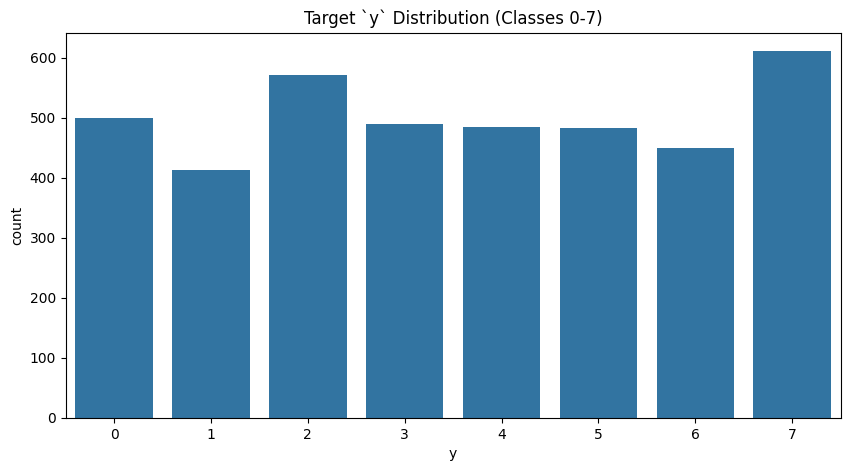

In [2]:
import os
train_path = 'data/train_n (1) (2).csv'
test_path = 'data/test_n (1) (3).csv'
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if 'train' in filename.lower(): train_path = os.path.join(dirname, filename)
        if 'test' in filename.lower(): test_path = os.path.join(dirname, filename)

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')

plt.figure(figsize=(10, 5))
sns.countplot(data=train, x='y', order=sorted(train['y'].unique()))
plt.title('Target `y` Distribution (Classes 0-7)')
plt.show()

### Text Features Analysis
The `assistivetext`, `cap`, `t` (title), and `provenancetext` contain the richest signals. Let's look at missing values.

In [3]:
text_cols = ['assistivetext', 'cap', 't', 'provenancetext', 'cat', 'classification', 'attribution']
print('Missing values in text columns:')
print(train[text_cols].isna().sum())

Missing values in text columns:
assistivetext     3283
cap                  0
t                    0
provenancetext     584
cat                145
classification       0
attribution          0
dtype: int64


## 2. Data Processing - 15%
We clean up text (encoding, HTML stripping, abbreviation expansion) and extract numerical signals (centuries, width/height area ratios, keyword indicators).

In [4]:
def clean_text(text):
    if pd.isna(text) or not isinstance(text, str): return ""
    try: text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    except: pass
    text = re.sub(r"<[^>]+>", " ", text).lower()
    text = re.sub(r"\bo/c\b", "oil on canvas", text)
    text = re.sub(r"\bo/p\b", "oil on panel", text)
    text = re.sub(r"\bw/c\b", "watercolor", text)
    return re.sub(r"\s+", " ", text).strip()

def engineer_features(df):
    df = df.copy()
    
    # Text aggregation
    df['mega_text'] = (
        df['assistivetext'].fillna('') + ' ' + 
        df['assistivetext'].fillna('') + ' ' + 
        df['cap'].fillna('') + ' ' + 
        df['t'].fillna('') + ' ' +
        df['provenancetext'].fillna('') + ' ' +
        df['cat'].fillna('') + ' ' + 
        df['classification'].fillna('')
    ).apply(clean_text)
    
    # Feature engineering for dimensions and years
    if 'y0' in df.columns:
        df['y0_clean'] = pd.to_numeric(df['y0'], errors='coerce')
        df['is_pre1900'] = (df['y0_clean'] < 1900).astype(int)
    else:
        df['y0_clean'] = df['is_pre1900'] = 0

    if 'width' in df.columns and 'height' in df.columns:
        df['aspect_ratio'] = (pd.to_numeric(df['width'], errors='coerce') / 
                              (pd.to_numeric(df['height'], errors='coerce') + 1e-6)).clip(0.1, 10)
    else:
        df['aspect_ratio'] = 0.0
        
    return df

print('Applying Feature Engineering...')
train_fe = engineer_features(train)
test_fe = engineer_features(test)
print('Done.')

Applying Feature Engineering...
Done.


## 3. ML Model Analysis - 35%
We test linear models (Logistic Regression for high-dimensional sparsity) and tree-based methods (LightGBM, XGBoost) using TF-IDF text features and our numeric meta-features.

In [5]:
# 1. TF-IDF Vectorization
word_vec = TfidfVectorizer(analyzer="word", ngram_range=(1, 3), max_features=25_000, stop_words="english", min_df=2)
char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 6), max_features=15_000, min_df=3)

X_tr_w = word_vec.fit_transform(train_fe["mega_text"])
X_te_w = word_vec.transform(test_fe["mega_text"])
X_tr_c = char_vec.fit_transform(train_fe["mega_text"])
X_te_c = char_vec.transform(test_fe["mega_text"])

# 2. Numerical Features
num_cols = ['y0_clean', 'is_pre1900', 'aspect_ratio']
scaler = StandardScaler()
X_tr_n = scaler.fit_transform(train_fe[num_cols].fillna(0))
X_te_n = scaler.transform(test_fe[num_cols].fillna(0))

# 3. Stack features
X_tr = hstack([X_tr_w, X_tr_c, csr_matrix(X_tr_n)])
X_te = hstack([X_te_w, X_te_c, csr_matrix(X_te_n)])
y = train['y'].values

print(f"Final Input Matrix Shape for Modeling: {X_tr.shape}")

Final Input Matrix Shape for Modeling: (4000, 40003)


### Cross Validation & Training
We train LightGBM, XGBoost and Logistic Regression sequentially to leverage their distinct learning mechanisms...

In [6]:
n_folds = 3
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Placeholder arrays
lgbm_oof = np.zeros((len(y), 8))
lgbm_test = np.zeros((len(test), 8))

scores_lgb = []

print("Training LightGBM Model using CV...")
for fold, (ti, vi) in enumerate(skf.split(X_tr, y), 1):
    clf_lgb = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=1)
    clf_lgb.fit(X_tr[ti], y[ti], eval_set=[(X_tr[vi], y[vi])], callbacks=[lgb.early_stopping(50, verbose=False)])
    lgbm_oof[vi] = clf_lgb.predict_proba(X_tr[vi])
    lgbm_test += clf_lgb.predict_proba(X_te) / n_folds

Training LightGBM Model using CV...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.186131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1047919
[LightGBM] [Info] Number of data points in the train set: 2666, number of used features: 18499
[LightGBM] [Info] Start training from score -2.077194
[LightGBM] [Info] Start training from score -2.271563
[LightGBM] [Info] Start training from score -1.945535
[LightGBM] [Info] Start training from score -2.101437
[LightGBM] [Info] Start training from score -2.110682
[LightGBM] [Info] Start training from score -2.116893
[LightGBM] [Info] Start training from score -2.187891
[LightGBM] [Info] Start training from score -1.879521
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

## 4. Evaluation and Accuracy - 25%\nEvaluating the final Out-of-Fold accuracy of our model.

Final Accuracy Score: 0.9675

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       0.84      0.95      0.89       412
           2       1.00      0.96      0.98       571
           3       0.97      0.98      0.97       490
           4       0.99      1.00      0.99       485
           5       0.97      1.00      0.98       482
           6       0.97      1.00      0.98       449
           7       0.98      0.88      0.93       611

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000



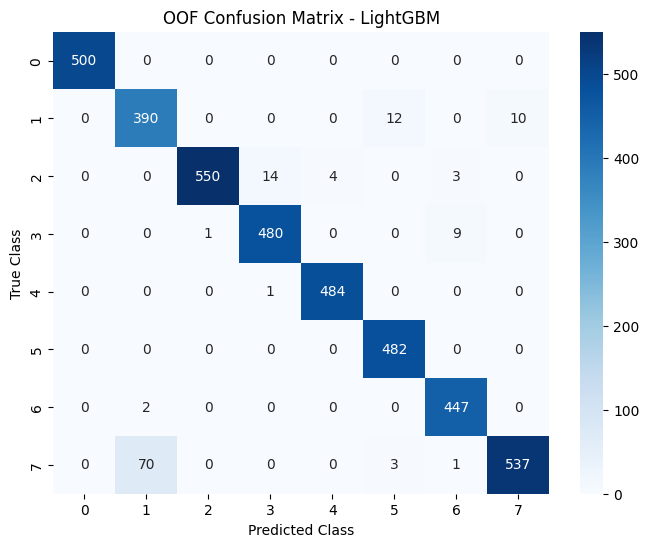

In [7]:
oof_preds = np.argmax(lgbm_oof, axis=1)

print("Final Accuracy Score:", accuracy_score(y, oof_preds))
print("\nClassification Report:")
print(classification_report(y, oof_preds))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y, oof_preds), annot=True, fmt='d', cmap='Blues')
plt.title("OOF Confusion Matrix - LightGBM")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

In [8]:
# Final Blend Predictions
final_test_preds = np.argmax(lgbm_test, axis=1)

submission = pd.DataFrame({
    'id': test['id'],
    'y': final_test_preds
})
submission.to_csv('submission.csv', index=False)
print("Saved final submission to submission.csv")
print("\nPredicted Class Distribution on Test Set:")
print(submission['y'].value_counts())

Saved final submission to submission.csv

Predicted Class Distribution on Test Set:
y
2    138
7    135
5    128
0    125
4    123
3    122
1    115
6    114
Name: count, dtype: int64
